# Linear Regression Baseline

目标：
使用高相关特征建立房价预测基线模型

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [13]:
df = pd.read_csv("../data/kaggle_cache/competitions/house-prices-advanced-regression-techniques/train.csv")

In [14]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt"
]

X = df[features]
y = df["SalePrice"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
pred = model.predict(X_test)

In [18]:
print("R² =", r2_score(y_test, pred))
print("RMSE =", mean_squared_error(
    y_test,
    pred
)**0.5)

R² = 0.793865396635656
RMSE = 39763.295265780616


In [19]:
for name, coef in zip(features, model.coef_):
    print(name, coef)

OverallQual 20392.513001014442
GrLivArea 48.80980118759696
GarageCars 15144.237203506369
TotalBsmtSF 25.36531866067783
YearBuilt 315.92335034468454


Text(0, 0.5, 'Predicted')

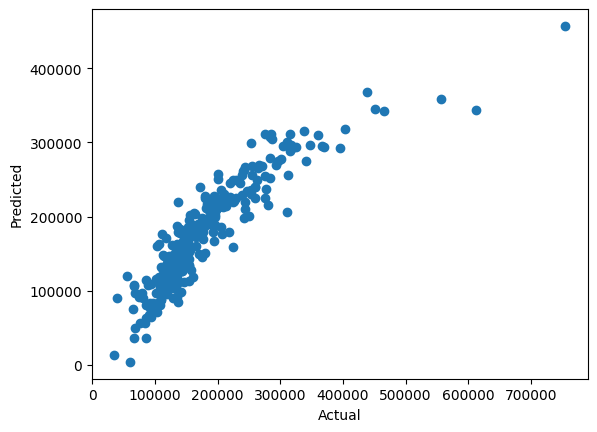

In [20]:
plt.scatter(y_test, pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

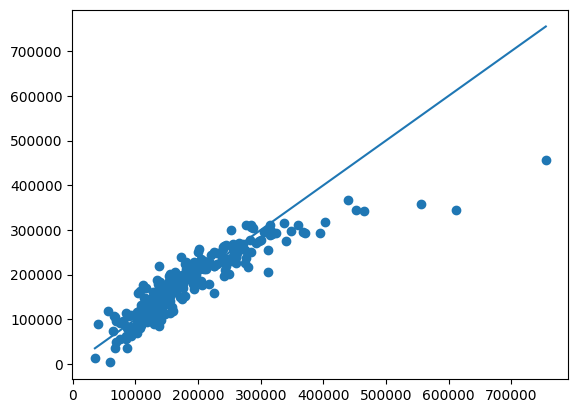

In [21]:
plt.scatter(y_test, pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

结果分析：

- 基线模型达到较好预测效果
- OverallQual 与 GrLivArea 对价格影响显著
- 后续考虑使用 Random Forest 和 XGBoost 提升性能